only attention layer and remove positional embedding and reimplement

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

device = 'cuda' if torch.cuda.is_available() else 'cpu'

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# 1 Data preparation

In [4]:
import tensorflow_datasets as tfds

# Tải tập dữ liệu IMDB
# as_supervised=True sẽ trả về tuple (text, label)
imdb = tfds.load("imdb_reviews", split=["train", "test"], as_supervised=True)

train_data, test_data = imdb[0], imdb[1]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.OQH2Y5_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.OQH2Y5_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.OQH2Y5_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [9]:
from nltk.tokenize import word_tokenize
from collections import Counter
import tensorflow as tf

# Lowercase + tokenize từng câu rồi nối vào list lớn
# Iterate over the dataset to get text data
tokenizer = []
for text, label in train_data:
    tokenizer.append(word_tokenize(text.numpy().decode('utf-8').lower()))

# Đếm tần suất
counter = Counter()
for tokens in tokenizer:
    counter.update(tokens)

# Xây vocab
max_vocab_size = 20000
specials = ["<unk>", "<pad>", "<s>"]
most_common = counter.most_common(max_vocab_size - len(specials))

# Chuyển sang dạng list index -> word (itos) và word -> index (vocab)
vocab = specials + [word for word, _ in most_common]
word2idx = {word: idx for idx, word in enumerate(vocab)}

In [10]:
seq_len = 200
text_pipeline = lambda x: [word2idx.get(token, vocab.index("<unk>")) for token in word_tokenize(x.lower())]

def collate_batch(batch):
    text_list, label_list = [], []
    for sample in batch:
        label_list.append(sample["label"])
        text_processed = text_pipeline(sample["text"])[:seq_len]

        # Thêm token <s> vào đầu
        text_processed = [vocab.index("<s>")] + text_processed
        # Padding nếu chưa đủ độ dài
        if len(text_processed) < seq_len:
            pad_size = seq_len - len(text_processed)
            text_processed += [vocab.index("<pad>")] * pad_size
        else:
            text_processed = text_processed[:seq_len]

        text_list.append(text_processed)
    input_ids = torch.tensor(text_list, dtype=torch.int64)
    labels = torch.tensor(label_list, dtype=torch.int64)
    return input_ids, labels

In [32]:
from torch.utils.data import DataLoader
batch_size = 32

# Convert tf.data.Dataset to a list of dictionaries
train_data_list = []
for text, label in train_data:
    train_data_list.append({'text': text.numpy().decode('utf-8'), 'label': label.numpy()})

test_data_list = []
for text, label in test_data:
    test_data_list.append({'text': text.numpy().decode('utf-8'), 'label': label.numpy()})


train_loader = DataLoader(train_data_list,
                          batch_size=batch_size,
                          shuffle=True,
                          collate_fn=collate_batch,
                          drop_last=True)
test_loader = DataLoader(test_data_list,
                         batch_size=batch_size,
                         shuffle=False,
                         collate_fn=collate_batch,
                         drop_last=True)

# 2 Model

In [33]:
class MultiheadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiheadAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        assert self.head_dim * self.num_heads == self.embed_dim, "embed_dim must be divisible by num_heads"

        self.query_linear = nn.Linear(embed_dim, embed_dim)
        self.key_linear = nn.Linear(embed_dim, embed_dim)
        self.value_linear = nn.Linear(embed_dim, embed_dim)
        self.out_linear = nn.Linear(embed_dim, embed_dim)

    def forward(self, query, key, value):
        batch_size = query.size(0)

        # Linear projections
        query = self.query_linear(query)
        key = self.key_linear(key)
        value = self.value_linear(value)

        # Reshape for multihead Attention, đáng ra query.view(batch_size, num_heads, seq_len, head_dim)
        query = query.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2) # đưa num_heads ra vị trí thứ 2 để tính attention song song theo từng head dễ dàng
        key = key.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)

        # Scale dot-product attention
        scores =  torch.matmul(query, key.transpose(-2, -1)) / (self.head_dim ** 0.5)

        attention_weights = F.softmax(scores, dim=-1)
        context = torch.matmul(attention_weights, value)

        # Concatenate heads and apply final linear layer
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.embed_dim)
        output = self.out_linear(context)
        return output, attention_weights

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout):
        super(TransformerBlock, self).__init__()
        self.attn = MultiheadAttention(embed_dim=embed_dim,
                                        num_heads=num_heads)
        self.ffn = nn.Linear(in_features=embed_dim,
                             out_features=embed_dim)
        self.layernorm = nn.LayerNorm(normalized_shape=embed_dim, eps=1e-6)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value):
        attn_out, _ = self.attn(query, key, value)
        attn_out = self.dropout(attn_out)
        output = self.layernorm(query + attn_out)
        return output

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embed_dim, max_length, device):
        super().__init__()
        self.device = device
        self.word_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)

    def forward(self, x):
        output = self.word_emb(x)
        return output

class TransformerTextCls(nn.Module):
    def __init__(self, vocab_size, max_length, embed_dim, num_heads, dropout, device):
        super().__init__()
        self.embd_layer = TokenEmbedding(vocab_size, embed_dim, max_length, device)
        self.transformer_layer = TransformerBlock(embed_dim, num_heads, dropout)

        self.fc = nn.Linear(in_features=max_length*embed_dim, out_features=2)
    def forward(self, x):
        output = self.embd_layer(x)
        output = self.transformer_layer(output, output, output)
        output = nn.Flatten()(output)
        output = self.fc(output)
        return output

In [34]:
max_len = seq_len
embed_dim = 64
num_heads = 4
ff_dim = 64
drop_out = 0.2
model = TransformerTextCls(vocab_size=max_vocab_size,
                           max_length=max_len,
                           embed_dim=embed_dim,
                           num_heads=num_heads,
                           dropout=drop_out,
                           device=device)

In [35]:
x = torch.randint(0, max_vocab_size, (batch_size, seq_len))
output = model(x)
output.shape

torch.Size([32, 2])

In [36]:
num_epochs = 20
LR = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

# 3 Train, Evaluate

In [43]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    running_correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        running_correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = running_correct / total if total > 0 else 0
    return epoch_loss, epoch_accuracy

def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            test_loss += loss.item()
            correct += (predicted == labels).sum().item()

    test_loss = test_loss / len(loader)
    accuracy = correct / total if total > 0 else 0
    return test_loss, accuracy

In [44]:
import matplotlib.pyplot as plt

def run_experiment(learning_rate, num_epochs):
    # Lưu lại lịch sử
    train_losses, test_losses = [], []
    train_accuracies, test_accuracies = [], []

    print("⚙️ Running...")
    for epoch in range(num_epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_accuracy = evaluate_one_epoch(model, test_loader, criterion, device)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}")

    # Vẽ đồ thị loss và accuracy
    epochs = range(1, num_epochs + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss per Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy')
    plt.plot(epochs, test_accuracies, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy per Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return {
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accuracies": train_accuracies,
        "test_accuracies": test_accuracies
    }


⚙️ Running...
Epoch 1/20 | Train Loss: 0.9316, Train Acc: 0.6339 | Test Loss: 0.7923, Test Acc: 0.7100
Epoch 2/20 | Train Loss: 0.4418, Train Acc: 0.8269 | Test Loss: 0.7074, Test Acc: 0.7434
Epoch 3/20 | Train Loss: 0.2512, Train Acc: 0.9005 | Test Loss: 0.8058, Test Acc: 0.7430
Epoch 4/20 | Train Loss: 0.1431, Train Acc: 0.9461 | Test Loss: 0.8554, Test Acc: 0.7606
Epoch 5/20 | Train Loss: 0.0782, Train Acc: 0.9721 | Test Loss: 0.9802, Test Acc: 0.7463
Epoch 6/20 | Train Loss: 0.0370, Train Acc: 0.9886 | Test Loss: 1.1305, Test Acc: 0.7600
Epoch 7/20 | Train Loss: 0.0253, Train Acc: 0.9926 | Test Loss: 1.2028, Test Acc: 0.7643
Epoch 8/20 | Train Loss: 0.0171, Train Acc: 0.9949 | Test Loss: 1.3874, Test Acc: 0.7700
Epoch 9/20 | Train Loss: 0.0370, Train Acc: 0.9860 | Test Loss: 1.6434, Test Acc: 0.7650
Epoch 10/20 | Train Loss: 0.0342, Train Acc: 0.9875 | Test Loss: 1.7261, Test Acc: 0.7724
Epoch 11/20 | Train Loss: 0.0199, Train Acc: 0.9929 | Test Loss: 1.8254, Test Acc: 0.7829
Epoch

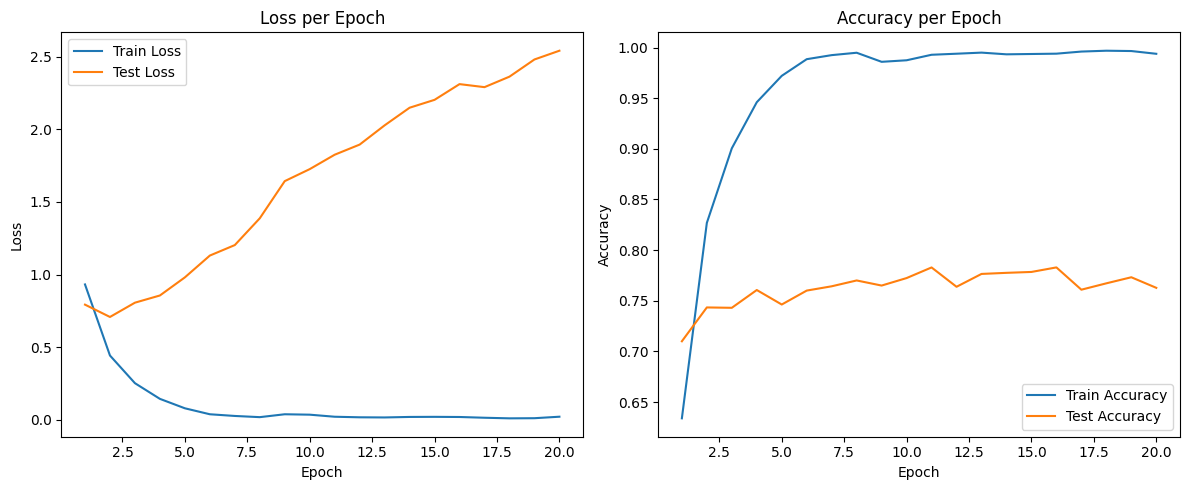

{'train_losses': [0.9315529656471272,
  0.44175982461925045,
  0.2511934597145351,
  0.14310716850046312,
  0.07815394696699653,
  0.03698614784593905,
  0.025333682129624037,
  0.017104496050749162,
  0.036995207325504854,
  0.03415075057852034,
  0.019920660314442562,
  0.016061297580432978,
  0.01502543494607776,
  0.01854364797610851,
  0.019209237229205672,
  0.018181500031561312,
  0.013001087535386247,
  0.008896946644756423,
  0.009839745535420582,
  0.020137900008703434],
 'test_losses': [0.7923178734036017,
  0.7074072071173432,
  0.8058417285583847,
  0.8554329720448592,
  0.9802094119077456,
  1.130485970741579,
  1.2027754709124565,
  1.387376625109917,
  1.6434099517581404,
  1.726051228213936,
  1.825358928857364,
  1.8951747225986249,
  2.027767173337742,
  2.149153126530092,
  2.203507450703775,
  2.3117733007468635,
  2.2909151259690486,
  2.363248518941192,
  2.4815707542336094,
  2.5419704878986566],
 'train_accuracies': [0.633882842509603,
  0.826904609475032,
  0.

In [46]:
model.to(device)
run_experiment(learning_rate=LR, num_epochs=num_epochs)

## 4 Prediction

In [47]:
def predict_sentiment(text, model, word2idx, vocab, seq_len, device):
    model.eval() # Chuyển mô hình sang chế độ đánh giá
    tokens = word_tokenize(text.lower())
    processed_text = [word2idx.get(token, vocab.index("<unk>")) for token in tokens]

    # Thêm token <s> vào đầu và padding
    processed_text = [vocab.index("<s>")] + processed_text
    if len(processed_text) < seq_len:
        pad_size = seq_len - len(processed_text)
        processed_text += [vocab.index("<pad>")] * pad_size
    else:
        processed_text = processed_text[:seq_len]

    # Chuyển đổi sang tensor và đưa lên device
    input_tensor = torch.tensor([processed_text], dtype=torch.int64).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)

    # Giải mã kết quả dự đoán
    sentiment = "Positive" if predicted.item() == 1 else "Negative"
    return sentiment

# Ví dụ sử dụng:
text_to_predict = "This movie was absolutely fantastic! I loved every moment of it."
predicted_sentiment = predict_sentiment(text_to_predict, model, word2idx, vocab, seq_len, device)
print(f"The sentiment of the text is: {predicted_sentiment}")

text_to_predict_2 = "I did not like this film at all. It was a complete waste of time."
predicted_sentiment_2 = predict_sentiment(text_to_predict_2, model, word2idx, vocab, seq_len, device)
print(f"The sentiment of the text is: {predicted_sentiment_2}")

The sentiment of the text is: Positive
The sentiment of the text is: Negative


## 5 Save Model Weights

In [49]:
# Define a path to save the model weights
model_save_path = '/content/drive/MyDrive/Colab Notebooks/Transformer/transformer_sentiment_model.pth'

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)

print(f"Model weights saved to {model_save_path}")

Model weights saved to /content/drive/MyDrive/Colab Notebooks/Transformer/transformer_sentiment_model.pth


## 6 Load Model Weights and Use for Prediction

In [ ]:
# Define the path to the saved model weights
model_save_path = "D:/Practice DL/Transformer/Transformer_Training/transformer_sentiment_model.pth"

# Create a new instance of the model with the same architecture
# Ensure all parameters like vocab_size, max_length, embed_dim, num_heads, dropout are the same as the trained model
loaded_model = TransformerTextCls(vocab_size=max_vocab_size,
                                  max_length=seq_len, # Use seq_len for max_length as defined earlier
                                  embed_dim=embed_dim,
                                  num_heads=num_heads,
                                  dropout=drop_out,
                                  device=device)

# Load the saved state dictionary into the new model instance
loaded_model.load_state_dict(torch.load(model_save_path, map_location=device))

# Move the loaded model to the appropriate device
loaded_model.to(device)

print("Model weights loaded successfully.")

# Use the loaded model for prediction (example)
text_to_predict_loaded = "This is a fantastic movie! I really enjoyed it."
predicted_sentiment_loaded = predict_sentiment(text_to_predict_loaded, loaded_model, word2idx, vocab, seq_len, device)
print(f"The sentiment of the text (using loaded model) is: {predicted_sentiment_loaded}")

text_to_predict_loaded_2 = "The acting was terrible and the plot was boring."
predicted_sentiment_loaded_2 = predict_sentiment(text_to_predict_loaded_2, loaded_model, word2idx, vocab, seq_len, device)
print(f"The sentiment of the text (using loaded model) is: {predicted_sentiment_loaded_2}")

Model weights loaded successfully.
The sentiment of the text (using loaded model) is: Positive
The sentiment of the text (using loaded model) is: Negative
